# Anomaly Detection in Network Traffic (Difficulty: 3 - Hard)

Project Objective: Build an anomaly detection system for network traffic data using a Hidden Markov Model. The aim is to identify unusual patterns that may indicate security threats or breaches.

# Imports and Installation

Let's install all the necessary packages and libraries.

In [2]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 9.5 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from hmmlearn.hmm import GaussianHMM

# "Bad" Dataset Part.
This section of the project tries to work with the initial dataset suggested in the project descirption. We will show that it is NOT suitable for this project.

## Data Preprocessing and EDA

### Data Preparation:
Preprocess the network traffic data, handling missing values and normalizing features.

In [4]:
df = pd.read_csv('/content/UNSW_NB15_training-set.csv')
print(df.shape)
print(df.head())

(82332, 45)
   id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0   1  0.000011   udp       -   INT      2      0     496       0   
1   2  0.000008   udp       -   INT      2      0    1762       0   
2   3  0.000005   udp       -   INT      2      0    1068       0   
3   4  0.000006   udp       -   INT      2      0     900       0   
4   5  0.000010   udp       -   INT      2      0    2126       0   

          rate  ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  \
0   90909.0902  ...                 1               2             0   
1  125000.0003  ...                 1               2             0   
2  200000.0051  ...                 1               3             0   
3  166666.6608  ...                 1               3             0   
4  100000.0025  ...                 1               3             0   

   ct_ftp_cmd  ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  \
0           0                 0           1           2               

We have plenty of columns and numerous rows, each represents a separate traffic note. They are NOT connected temporally or sequentially. This dataset is great for classificaiton-based anomaly detection (e.g., using random forests). However, for HMMs this is no good since a) there are no obvious hidden or observable states and b) we cannot connect different states with one another to use the Markov assumption


But we will try to work around it. We first create two behaviour classes: normal and attack, which are more or less balanced

In [5]:
num_df = df.select_dtypes(include=['int64', 'float64'])
num_df = num_df.dropna()

normal_df = num_df[df['label'] == 0].drop(columns=['label'])
attack_df = num_df[df['label'] == 1].drop(columns=['label'])

print(f"Normal traffic: {normal_df.shape}, Attack traffic: {attack_df.shape}")

Normal traffic: (37000, 40), Attack traffic: (45332, 40)


Then we standartize them

In [6]:
scaler = StandardScaler()
normal_scaled = scaler.fit_transform(normal_df)
attack_scaled = scaler.transform(attack_df)

# Feature Engineering:
Create time-series features such as packet counts, bytes transferred, and connection durations.

To use this data for HMM, we need to create state sequences. Let's write a custom function to do that

In [7]:
def create_sequences(data, seq_len=50):
    sequences = []
    for i in range(0, len(data) - seq_len, seq_len):
        sequences.append(data[i:i+seq_len])
    return sequences

normal_sequences = create_sequences(normal_scaled)
attack_sequences = create_sequences(attack_scaled)

print(f"# of normal sequences: {len(normal_sequences)}")

# of normal sequences: 739


We also need to account for different time steps in the chain. Let's create a function for that too:

In [10]:
def score_per_timestep(model, seq):
    return model.score(seq) / len(seq)

normal_scores = np.array([score_per_timestep(model, s) for s in normal_sequences])
attack_scores = np.array([score_per_timestep(model, s) for s in attack_sequences])

# Model Training:

Implement a Gaussian HMM using HMMlearn to model normal network behavior.

Fiannly, let's build an HMM model. We will be using Gaussisn with 3 components, since more components diverge. We will also use the 'diag' covariance since this is standard.

In [9]:
model = GaussianHMM(n_components=3, covariance_type='diag', n_iter=10, random_state=42)

train_data = np.vstack(normal_sequences)
lengths = [len(seq) for seq in normal_sequences]

print("Training HMM on normal traffic...")
model.fit(train_data, lengths)
print("Training complete.")

Training HMM on normal traffic...
Training complete.


In [12]:
print("Converged:", model.monitor_.converged)
print("Iters:", model.monitor_.iter)
print("LL history (last 10):", list(model.monitor_.history)[-10:])

Converged: True
Iters: 7
LL history (last 10): [-2035895.1256031692, -446072.13948299206, 476362.7512786715, 673472.0242806701, 735564.5537041859, 773215.5162116649, 773215.5162116643]


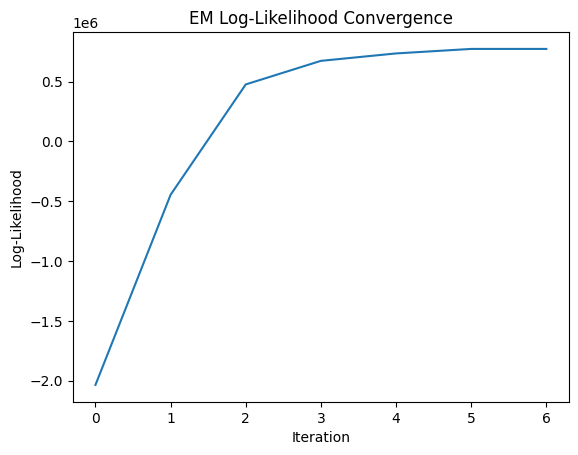

In [13]:
plt.plot(model.monitor_.history)
plt.title("EM Log-Likelihood Convergence")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.show()

We can see that the model converges super quickly, which is suspiious behavior for training. This is our first 'red flag' indicating that the dataset is not perfect

------
To prove that the problem is not in a randomly chosen model parameters, let's experiment with different number of components and increase the number of iterations.

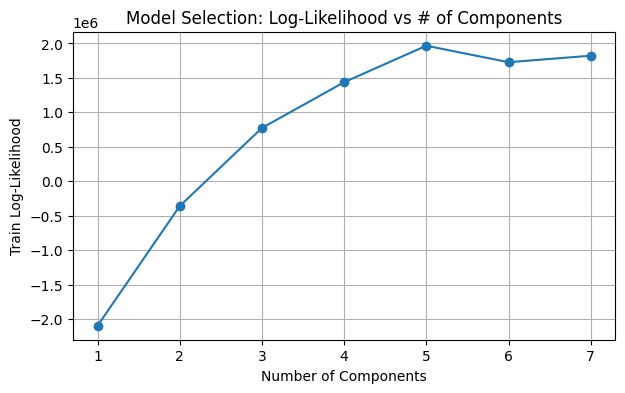

In [19]:
scores = []
component_range = range(1, 8)

for n in component_range:
    model = GaussianHMM(n_components=n, covariance_type='diag', n_iter=300, random_state=42)
    model.fit(train_data, lengths)
    score = model.score(train_data, lengths)
    scores.append(score)

plt.figure(figsize=(7, 4))
plt.plot(component_range, scores, marker='o')
plt.title("Model Selection: Log-Likelihood vs # of Components")
plt.xlabel("Number of Components")
plt.ylabel("Train Log-Likelihood")
plt.grid(True)
plt.show()


To compare the models, we will build a function evaluating log-likelihood scores and chose the best model based on this

In [20]:
def compute_scores(model, sequences):
    scores = [model.score(seq) for seq in sequences]
    return np.array(scores)

normal_scores = compute_scores(model, normal_sequences)
attack_scores = compute_scores(model, attack_sequences)

# Anomaly Detection and Evaluation:

## Anomaly Detection
Use the trained model to detect anomalies in live or historical network traffic data.

## Evaluation:

Assess the performance of the anomaly detection system using precision, recall, and F1-score metrics.

We need to define a threshold, which will discern between the normal traffic and attacks based on the log-likelihood. We can just choose a standard number, like 5%, and evaluate with these results:

In [21]:
threshold = np.percentile(normal_scores, 5)

normal_preds = (normal_scores < threshold).astype(int)  # expect 0
attack_preds = (attack_scores < threshold).astype(int)  # expect 1

y_true = np.array([0]*len(normal_preds) + [1]*len(attack_preds))
y_pred = np.concatenate([normal_preds, attack_preds])

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

Precision: 0.944, Recall: 0.691, F1: 0.798


Even with bad data, we get decent results. Let's plot the log-likelihood distributions for both types of traffic activity. It's very skewed but we cannot discard the outliers as they present the anomaly data, which we are looking for

# Visualization:

Visualize detected anomalies and normal traffic patterns using Seaborn or Matplotlib.

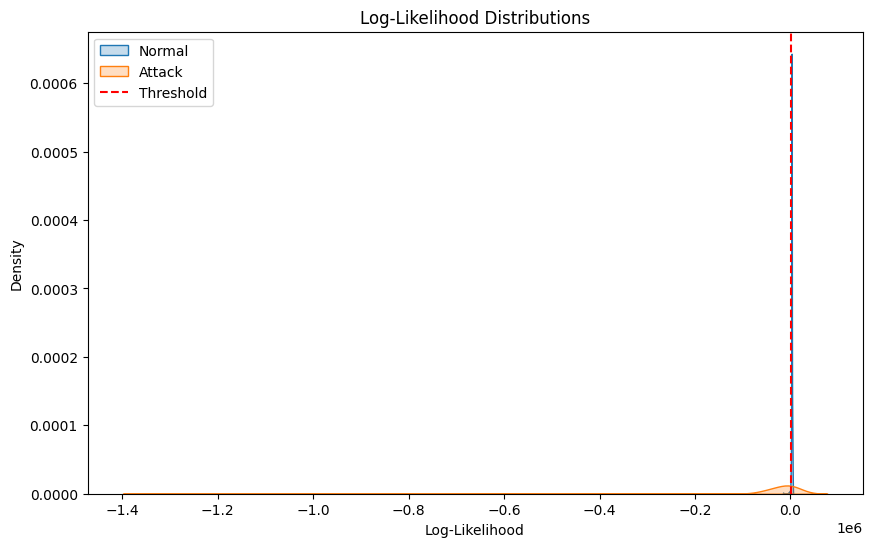

In [22]:
plt.figure(figsize=(10,6))
sns.kdeplot(normal_scores, label='Normal', fill=True)
sns.kdeplot(attack_scores, label='Attack', fill=True)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.title('Log-Likelihood Distributions')
plt.xlabel('Log-Likelihood')
plt.legend()
plt.show()

# Bonus:

Implement a feedback loop that retrains the model based on new traffic data to improve accuracy over time.

To do: try with new data

In [23]:
# new_data = scaler.transform(new_normal_samples)
# model.fit(np.vstack([train_data, new_data]))

# NEW "GOOD" DATA Section; CHECK WITH PROF and TA !!!


As I showed in the previous section, the initial dataset is not superb for this task. In order to explore the full capacity of HMMs, let's try traffic anonaly detection on a more suitable datset: CESNET-TimeSeries24: Time Series Dataset for Network Traffic Anomaly Detection and Forecasting (https://zenodo.org/records/13382427)

Why is it better?

The initial goal was to ensure the dataset is sequential and temporal, which is crucial for HMMs. So this dataset is:

1) Sequential/Temporal: It's a time-series dataset, meaning data points are ordered and dependent on time. This is essential for HMMs

2) Network Traffic: The description explicitly mentions "Network Traffic Anomaly Detection". So this dataset also hass relevant features (like packet rates, byte counts)

3) Format: Time-series data is well-structured and it simplifies data preparation and feature engineering

4) Availability/Access: THis dataset is hosted on Zenodo with a public record. Therefore, just like the initially suggested public datasets from Kaggle, anyonr can easily access this one too. , though we'll need to confirm the exact file size and format

# Data Preprocessing and EDA

In [24]:
df_raw = pd.read_csv('/content/42.csv')
print(df_raw.shape)
df_raw.info()

(6717, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6717 entries, 0 to 6716
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_time                6717 non-null   int64  
 1   n_flows                6717 non-null   int64  
 2   n_packets              6717 non-null   int64  
 3   n_bytes                6717 non-null   int64  
 4   sum_n_dest_asn         6717 non-null   int64  
 5   average_n_dest_asn     6717 non-null   float64
 6   std_n_dest_asn         6717 non-null   float64
 7   sum_n_dest_ports       6717 non-null   int64  
 8   average_n_dest_ports   6717 non-null   float64
 9   std_n_dest_ports       6717 non-null   float64
 10  sum_n_dest_ip          6717 non-null   int64  
 11  average_n_dest_ip      6717 non-null   float64
 12  std_n_dest_ip          6717 non-null   float64
 13  tcp_udp_ratio_packets  6717 non-null   float64
 14  tcp_udp_ratio_bytes    6717 non-null   float6

In [30]:
df = df_raw.drop(columns=['sum_n_dest_asn', 'sum_n_dest_ports', 'sum_n_dest_ip'])
print(df.shape)
df_raw.info()

(6717, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6717 entries, 0 to 6716
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_time                6717 non-null   int64  
 1   n_flows                6717 non-null   int64  
 2   n_packets              6717 non-null   int64  
 3   n_bytes                6717 non-null   int64  
 4   sum_n_dest_asn         6717 non-null   int64  
 5   average_n_dest_asn     6717 non-null   float64
 6   std_n_dest_asn         6717 non-null   float64
 7   sum_n_dest_ports       6717 non-null   int64  
 8   average_n_dest_ports   6717 non-null   float64
 9   std_n_dest_ports       6717 non-null   float64
 10  sum_n_dest_ip          6717 non-null   int64  
 11  average_n_dest_ip      6717 non-null   float64
 12  std_n_dest_ip          6717 non-null   float64
 13  tcp_udp_ratio_packets  6717 non-null   float64
 14  tcp_udp_ratio_bytes    6717 non-null   float6

Let's get rid of useless or duplicating features

In [31]:
df = df.drop(columns=['id_time','std_n_dest_asn', 'std_n_dest_ports', 'std_n_dest_ip'])
print(df.shape)
df.info()

(6717, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6717 entries, 0 to 6716
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   n_flows                6717 non-null   int64  
 1   n_packets              6717 non-null   int64  
 2   n_bytes                6717 non-null   int64  
 3   average_n_dest_asn     6717 non-null   float64
 4   average_n_dest_ports   6717 non-null   float64
 5   average_n_dest_ip      6717 non-null   float64
 6   tcp_udp_ratio_packets  6717 non-null   float64
 7   tcp_udp_ratio_bytes    6717 non-null   float64
 8   dir_ratio_packets      6717 non-null   float64
 9   dir_ratio_bytes        6717 non-null   float64
 10  avg_duration           6717 non-null   float64
 11  avg_ttl                6717 non-null   float64
dtypes: float64(9), int64(3)
memory usage: 629.8 KB


Let's split the data into train and test datasets, there is no target column for Markov chains here. Then we will standartize the data like we did with the 'bad' dataset.

In [32]:
X_train, X_test = sklearn.model_selection.train_test_split(df, test_size=0.2)

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Training: let's choose the best model again

In [34]:
scores, models = [], []

for n in range(1,7):
  model = GaussianHMM(n_components=n, covariance_type='diag', n_iter=10000, random_state=2)
  model.fit(X_train_scaled)
  scores.append(model.score(X_train_scaled))
  models.append(model)

In [35]:
# see all the scores for different n
for score in scores:
  print(score)

-91487.48086696058
-51647.78679493538
-44085.57978063558
-41021.55508627407
-36862.89934752304
-34287.258405745364


In [36]:
best_model = models[np.argmax(scores)] # n=6, then it diverges; btw, why?
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5373 entries, 5197 to 2731
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   n_flows                5373 non-null   int64  
 1   n_packets              5373 non-null   int64  
 2   n_bytes                5373 non-null   int64  
 3   average_n_dest_asn     5373 non-null   float64
 4   average_n_dest_ports   5373 non-null   float64
 5   average_n_dest_ip      5373 non-null   float64
 6   tcp_udp_ratio_packets  5373 non-null   float64
 7   tcp_udp_ratio_bytes    5373 non-null   float64
 8   dir_ratio_packets      5373 non-null   float64
 9   dir_ratio_bytes        5373 non-null   float64
 10  avg_duration           5373 non-null   float64
 11  avg_ttl                5373 non-null   float64
dtypes: float64(9), int64(3)
memory usage: 545.7 KB


# Feature Engineering

We need to segment our data into 24h windows and then evaluate the score of each segment for the distribution to find anomalies

In [37]:
def segmentation(data, w=24, overlap=12):
  segments = []
  step = w - overlap
  for i in range(0, len(data) - w + 1, step):
    segments.append(data[i:i+w])
  return segments

def segment_score(model, segments):
  scores = [model.score(segment) for segment in segments]
  return np.array(scores)

In [38]:
# calculate the "Normalcy Score" Distribution (Training Set)
normal_segments = segmentation(X_train_scaled)
normal_scores = segment_score(best_model, normal_segments)

# Model Training

Let's train the best model and experiment with the best threshold for anomaly discerning

In [39]:
# Calculate the P-th percentile of these normal scores
threshold = np.percentile(normal_scores, 5)
print(threshold)

-3231.6784377956237


# Visualization

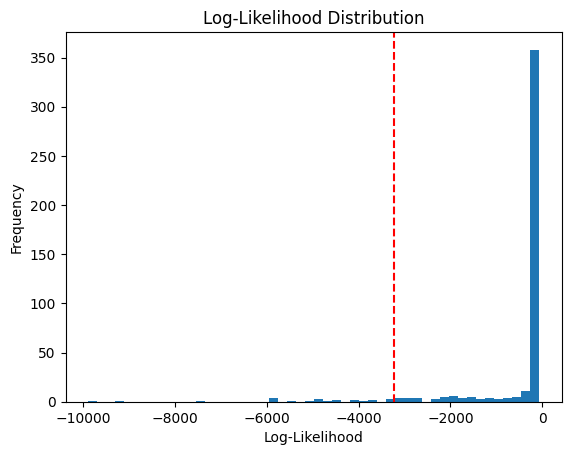

In [40]:
plt.hist(normal_scores, bins=50,label='Normal')
plt.title('Log-Likelihood Distribution')
plt.xlabel('Log-Likelihood')
plt.ylabel('Frequency')
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')


Candidate Percentiles: [ 1  2  3  4  5  6  7  8  9 10]
Scores at Percentiles: [np.float64(-5905.805852913674), np.float64(-4960.319615108595), np.float64(-4485.9334318765705), np.float64(-3703.46242486988), np.float64(-3231.6784377956237), np.float64(-3001.199860606881), np.float64(-2773.550292312639), np.float64(-2349.388269226264), np.float64(-2173.8189463076565), np.float64(-1920.6886858196451)]
Score Differences (Drop): [945.48623781 474.38618323 782.47100701 471.78398707 230.47857719
 227.64956829 424.16202309 175.56932292 253.13026049]
Recommended Best Percentile (P): 9
Recommended Best Threshold (Score): -2173.8189463076565


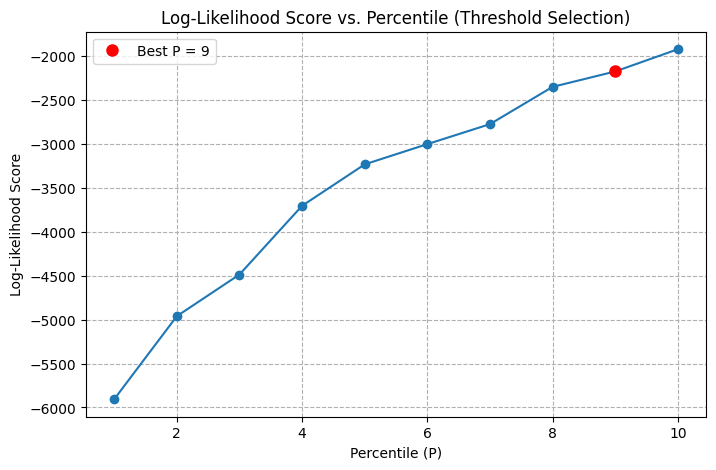

In [41]:
percentile_range = np.arange(1, 11) # 1st through 10th percentiles
scores_at_percentiles = [np.percentile(normal_scores, p) for p in percentile_range]
score_diffs = np.diff(scores_at_percentiles)
best_p_index = np.argmin(score_diffs)

best_p = percentile_range[best_p_index + 1]
best_threshold = scores_at_percentiles[best_p_index + 1]

print(f"Candidate Percentiles: {percentile_range}")
print(f"Scores at Percentiles: {scores_at_percentiles}")
print(f"Score Differences (Drop): {score_diffs}")
print(f"Recommended Best Percentile (P): {best_p}")
print(f"Recommended Best Threshold (Score): {best_threshold}")


plt.figure(figsize=(8, 5))
plt.plot(percentile_range, scores_at_percentiles, marker='o', linestyle='-')
plt.plot(best_p, best_threshold, 'ro', markersize=8, label=f'Best P = {best_p}')
plt.title('Log-Likelihood Score vs. Percentile (Threshold Selection)')
plt.xlabel('Percentile (P)')
plt.ylabel('Log-Likelihood Score')
plt.grid(True, linestyle='--')
plt.legend()
plt.savefig("percentile_selection.png")

# Evaluation and Anomaly Detection:

Let's find the test scores using the same segmentation parameters. Then we will use it for flag anomalies

In [42]:
test_segments = segmentation(X_test_scaled, w=24, overlap=12)
test_scores = segment_score(best_model, test_segments)

anomalies_detected = test_scores < threshold
anomaly_flags = anomalies_detected.astype(int)

print(f"Total test segments scored: {len(test_scores)}")
print(f"Total segments flagged as anomalies: {np.sum(anomaly_flags)}")

Total test segments scored: 111
Total segments flagged as anomalies: 5


In [43]:
window_size = 24
overlap = 12
step = window_size - overlap

original_start_indices = X_test.index[0]

segment_start_indices = []
for i in range(0, len(X_test_scaled) - window_size + 1, step):
    segment_start_indices.append(X_test.index[i])

# Create a DataFrame to hold the scores and flags mapped to their starting time index
results_df = pd.DataFrame({
    'start_index': segment_start_indices,
    'log_likelihood_score': test_scores,
    'anomaly_flag': anomaly_flags
})

print("\n--- Detected Anomalies (First 5) ---")
print(results_df[results_df['anomaly_flag'] == 1].head())


--- Detected Anomalies (First 5) ---
    start_index  log_likelihood_score  anomaly_flag
23         1687          -5486.743659             1
46         5282         -11541.396718             1
51         1231          -3758.793024             1
81          173          -3504.205236             1
93         2407          -3338.881581             1


Let's view all the segmetn sequence we have to find anomalies

In [44]:
segment_sequence = results_df.index.values
segment_sequence

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110])

In [45]:
anomalies = results_df[results_df['anomaly_flag'] == 1] # Filter the DataFrame for flagged points
anomalies

,start_index,log_likelihood_score,anomaly_flag
23,1687,-5486.743659,1
46,5282,-11541.396718,1
51,1231,-3758.793024,1
81,173,-3504.205236,1
93,2407,-3338.881581,1


# Visualization (again)

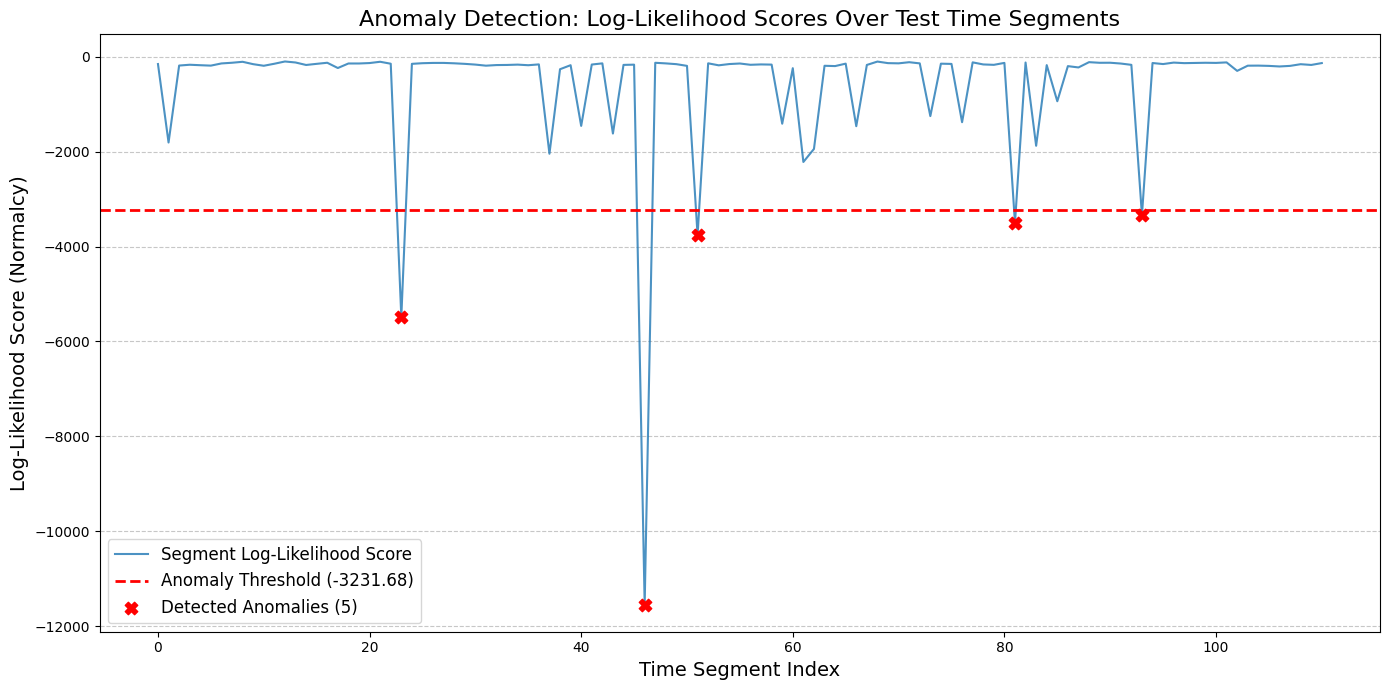

In [46]:
plt.figure(figsize=(14, 7))

# Plot all log-likelihood scores as a line (Baseline)
plt.plot(segment_sequence, results_df['log_likelihood_score'],
         label='Segment Log-Likelihood Score',
         color='tab:blue',
         linewidth=1.5,
         alpha=0.8)

# Add the anomaly threshold line
plt.axhline(threshold, color='red', linestyle='--', linewidth=2,
            label=f'Anomaly Threshold ({threshold:.2f})')


plt.scatter(anomalies.index.values,
            anomalies['log_likelihood_score'],
            color='red',
            s=80,
            marker='X',
            zorder=5,
            label=f'Detected Anomalies ({len(anomalies)})')

plt.title('Anomaly Detection: Log-Likelihood Scores Over Test Time Segments', fontsize=16)
plt.xlabel('Time Segment Index', fontsize=14)
plt.ylabel('Log-Likelihood Score (Normalcy)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Evaluation Report

Something goes wrong here as the results are unexpectedly low. This is what I will be addressing next. Once I figure it out, I only need to create the presentation and report my work

In [47]:
from sklearn.metrics import precision_recall_fscore_support, classification_report


def simulate_anomalies(df_test, feature_multiplier=15, num_anomalies=5, window_size=24):
    df_simulated = df_test.copy()
    np.random.seed(42)
    available_indices = np.arange(0, len(df_test) - window_size, window_size + 10)
    anomaly_starts = np.random.choice(available_indices, size=num_anomalies, replace=False)

    for start_idx in anomaly_starts:
        end_idx = start_idx + window_size

        # Drastically increase key volume features to simulate anomalies
        df_simulated.iloc[start_idx:end_idx, df_simulated.columns.get_loc('n_flows')] *= feature_multiplier
        df_simulated.iloc[start_idx:end_idx, df_simulated.columns.get_loc('n_packets')] *= feature_multiplier
        df_simulated.iloc[start_idx:end_idx, df_simulated.columns.get_loc('n_bytes')] *= feature_multiplier

    return df_simulated, anomaly_starts

def create_ground_truth(segment_indices, anomaly_starts, window_size=24, tolerance=12):
    y_true = np.zeros(len(segment_indices), dtype=int)

    for i, seg_start in enumerate(segment_indices):
        for anom_start in anomaly_starts:
            # Check if the segment overlaps/starts near a true anomaly event
            if anom_start <= seg_start < (anom_start + window_size + tolerance):
                y_true[i] = 1
                break
    return y_true

In [55]:
# Parameters
window_size = 24
overlap = 12
threshold = best_threshold

# A. Simulate Anomalies (Generates Y_true)
X_test_simulated_unscaled, true_anomaly_starts = simulate_anomalies(X_test, window_size=window_size)

# B. Scale and Score the Simulated Data (Generates Y_pred)
X_test_simulated_scaled = scaler.transform(X_test_simulated_unscaled)
simulated_segments = segmentation(X_test_simulated_scaled, w=window_size, overlap=overlap)
simulated_scores = segment_score(best_model, simulated_segments)
Y_pred = (simulated_scores < threshold).astype(int)

# C. Generate Ground Truth Labels (Y_true)
segment_start_indices = [i * (window_size - overlap) for i in range(len(simulated_scores))]
Y_true = create_ground_truth(segment_start_indices, true_anomaly_starts, window_size=window_size)

# D. Final Evaluation
print("\n--- Evaluation Metrics (Simulated Anomalies) ---")

# Calculate metrics for the 'anomaly' class (label=1)
precision, recall, f1_score, support = precision_recall_fscore_support(
    Y_true, Y_pred, average='binary', pos_label=1
)
print(classification_report(Y_true, Y_pred, target_names=['Normal', 'Anomaly']))

print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1_score:.4f}")


--- Evaluation Metrics (Simulated Anomalies) ---
              precision    recall  f1-score   support

      Normal       0.91      0.89      0.90        96
     Anomaly       0.39      0.47      0.42        15

    accuracy                           0.83       111
   macro avg       0.65      0.68      0.66       111
weighted avg       0.84      0.83      0.84       111


Precision: 0.3889
Recall:    0.4667
F1-Score:  0.4242


In [56]:
scores_at_percentiles[9]

np.float64(-1920.6886858196451)